<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter04_%EB%B6%84%EB%A5%98(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


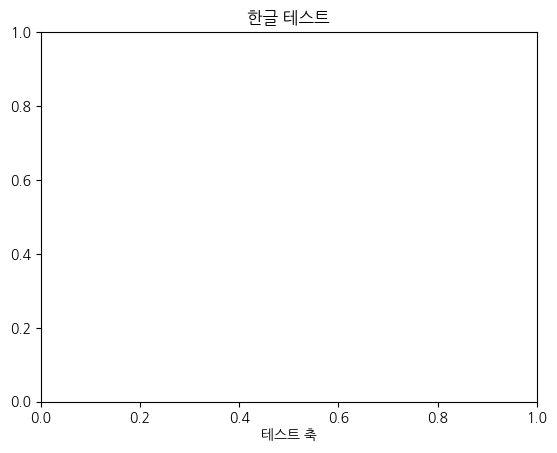

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 사이킷런 유방암 데이터셋
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, roc_auc_score
)

dataset = load_breast_cancer()
cancer_df = pd.DataFrame(
    data=dataset.data,
    columns=dataset.feature_names
)
cancer_df['target'] = dataset.target

# 독립변수(X)와 종속변수(y) 분리
X_features = cancer_df.iloc[:, :-1]
y_label    = cancer_df.iloc[:, -1]

#전체 데이터셋을 학습(80%)과 테스트(20%) 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label,
    test_size=0.2,
    random_state=156 # 데이터 분할의 재현성을 위해 랜덤 시드 고정
)
#학습셋(X_train, y_train)을 다시 학습(90%)과 검증(10%) 세트로 분할
#검증셋은 Early Stopping 모니터링에만 사용되며(학습에서는 사용X), 최종 성능 평가는 테스트셋으로 진행
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=156
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)


X_train: (455, 30) | X_test: (114, 30)
y_train: (455,) | y_test: (114,)


In [ ]:
# 통합 평가 함수
def get_clf_eval(y_test, pred=None, pred_proba=None, model_name=''):
  confusion = confusion_matrix(y_test, pred) # 오차 행렬 계산
  accuracy = accuracy_score(y_test, pred)   # 정확도 계산
  precision = precision_score(y_test, pred) # 정밀도 계산
  recall = recall_score(y_test, pred)         # 재현율 계산
  f1 = f1_score(y_test, pred)               # F1 스코어 계산
  roc_auc = roc_auc_score(y_test, pred_proba) # ROC AUC 스코어 계산

  title = f'=== {model_name} ===' if model_name else '=== 모델 성능 ==='
  print(title)
  print('오차 행렬')
  print(confusion)
  print(
      f'정확도:{accuracy:.4f} | 정밀도:{precision:.4f} |'
      f'재현율:{recall:.4f} | F1:{f1:.4f} | AUC:{roc_auc:.4f}'
  )


### XGBoost - 파이썬 래퍼(xgb.train)

In [ ]:
from ast import increment_lineno
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

# XGBoost 전용 데이터 구조
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

# 주요 하이퍼파라미터
params = {
    'max_depth': 3, # 개별 트리의 최대 깊이
    'eta' : 0.05, # 학습률(learning_rate)
    'objective' : 'binary:logistic', #모델이 최적화할 목적 함수:이진 분류:로지스틱 회귀의 손실 함수
    'eval_metric' : 'logloss' # 평가 지표: logloss는 확률 예측의 정확도를 별점화, 값이 낮을수록 좋다
}
num_rounds = 400 # 최대 부스팅 라운드 수, 생성할 트리의 최대 계수

# 학습 실행
eval_list = [(dtr,'train'), (dval,'eval')] # 모니터링 리스트를 튜플로 수정
xgb_model = xgb.train(
    params = params,
    dtrain = dtr,
    num_boost_round = num_rounds,
    early_stopping_rounds = 50, # 검증 성능 개선이 없는 최대 라운드 수
    evals = eval_list # 학습 중 모니터링할 데이터셋 리스트
)
print(f'\n학습 완료! 최적 라운드: {xgb_model.best_iteration}')
print(f'최적 라운드의 검증 logloss: {xgb_model.best_score:.6f}')

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

In [ ]:
# 예측 및 평가
pred_probs = xgb_model.predict(dtest) # 양성(1) 클래스 예측 확률값 배열
print('예측 확률 값 앞 10개:')
print(np.round(pred_probs[:10],3))

# 임계값 0.5 : 확률 >= 0.5 -> 1(양성), < 0.5 -> 0(음성)
preds = [1 if p > 0.5 else 0 for p in pred_probs]
print('예측 레이블 앞 10개:', preds[:10])

# 최종 성능 평가
get_clf_eval(y_test, preds, pred_probs, 'XGBoost 파이썬 래퍼')

예측 확률 값 앞 10개:
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측 레이블 앞 10개: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]
=== XGBoost 파이썬 래퍼 ===
오차 행렬
[[35  2]
 [ 2 75]]
정확도:0.9649 | 정밀도:0.9740 |재현율:0.9740 | F1:0.9740 | AUC:0.9965


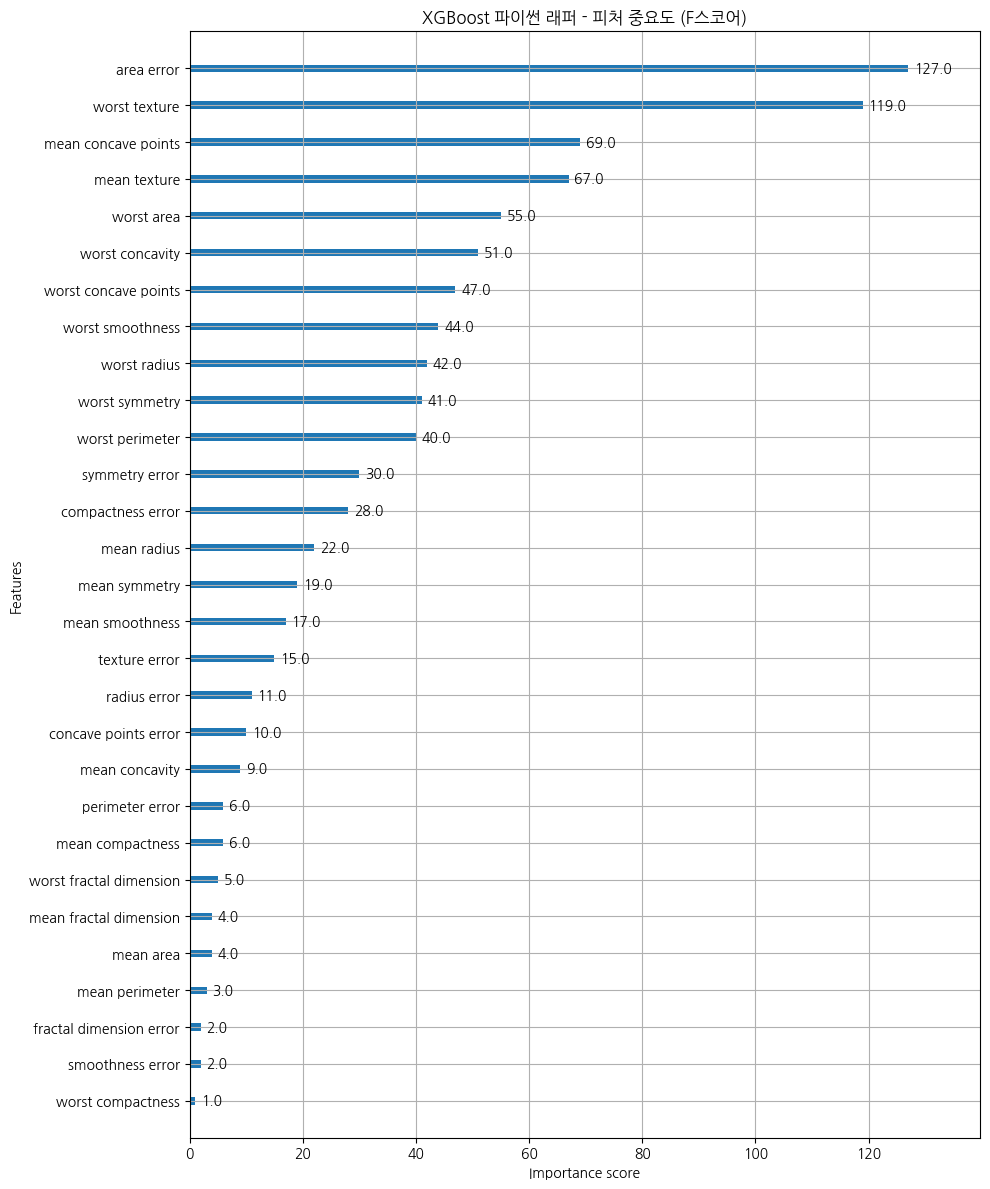

In [ ]:
# 피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)
plt.title('XGBoost 파이썬 래퍼 - 피처 중요도 (F스코어)')
plt.tight_layout()
plt.show()

In [ ]:
from xgboost.callback import EarlyStopping
from xgboost import XGBClassifier # Import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth = 3,
    eval_metric = 'logloss',
    random_state = 156,
    callbacks = [EarlyStopping(rounds=100, save_best=True, maximize=False)] # logloss는 낮을수록 좋으므로 False
)
#Early Stopping 모니터링
evals = [(X_tr, y_tr),(X_val, y_val)]

xgb_wrapper.fit(X_tr, y_tr, eval_set = evals, verbose = True) # 매 라운드 logloss 출력
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1] # ['음성 확률','양성 확률']

get_clf_eval(y_test, w_preds, w_pred_proba, 'XGBoost 사이킷런 래퍼 (Early Stopping=100)')

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [ ]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators = 400, # 부스팅 트리 수 (최대 라운드)
    learning_rate = 0.1,
    max_depth = 3,
    eval_metric = 'logloss',
    random_state = 156
)
xgb_wrapper.fit(X_train, y_train)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, w_preds, w_pred_proba, 'XGBoost 사이킷런 래퍼 (기본)')

=== XGBoost 사이킷런 래퍼 (기본) ===
오차 행렬
[[35  2]
 [ 1 76]]
정확도:0.9737 | 정밀도:0.9744 |재현율:0.9870 | F1:0.9806 | AUC:0.9951


In [ ]:
from xgboost.callback import EarlyStopping
from xgboost import XGBClassifier # Import XGBClassifier

xgb_wrapper3 = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth = 3,
    eval_metric = 'logloss',
    random_state = 156,
    callbacks = [EarlyStopping(rounds=10, save_best=True, maximize=False)] # logloss는 낮을수록 좋으므로 False
)
#Early Stopping 모니터링
evals = [(X_tr, y_tr),(X_val, y_val)]

xgb_wrapper3.fit(X_tr, y_tr, eval_set = evals, verbose = True) # 매 라운드 logloss 출력
w_preds = xgb_wrapper3.predict(X_test)
w_pred_proba = xgb_wrapper3.predict_proba(X_test)[:, 1] # ['음성 확률','양성 확률']

get_clf_eval(y_test, w_preds, w_pred_proba, 'XGBoost 사이킷런 래퍼 (Early Stopping=10)')

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

### LightGBM

In [ ]:
from lightgbm import LGBMClassifier, plot_importance
from lightgbm.callback import early_stopping

lgbm_wrapper = LGBMClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    objective = 'binary',
    min_child_samples= 5, # 기본값 20 -> 줄이면 더 잘게 분기 가능
)
evals = [(X_tr,y_tr),(X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr,
                 eval_set = evals, # eval_set 인자 추가
                 eval_metric = 'logloss',
                 callbacks=[early_stopping(stopping_rounds=50, verbose=True)],)
preds           = lgbm_wrapper.predict(X_test)
pred_proba      = lgbm_wrapper.predict_proba(X_test)[:, 1] # ['음성 확률','양성 확률']

get_clf_eval(y_test, preds, pred_proba, 'LightGBM')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

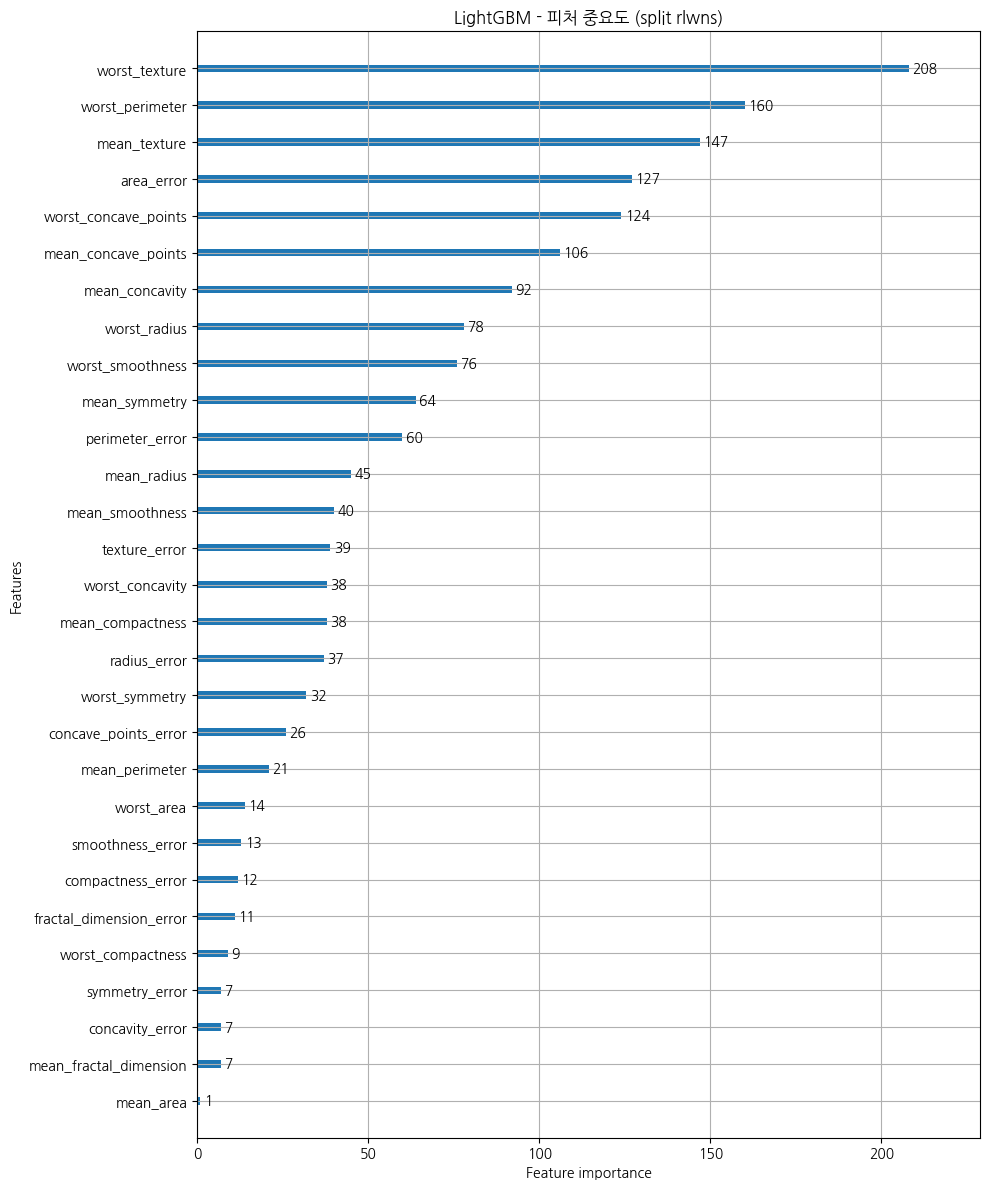

In [ ]:
# 피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper, ax=ax)
plt.title('LightGBM - 피처 중요도 (split rlwns)')
plt.tight_layout()
plt.show()

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
import catboost
print('CatBoost 버전:', catboost.__version__)

CatBoost 버전: 1.2.10


In [ ]:
from catboost import CatBoostClassifier, Pool

# Pool: CallBoost 전용 데이터 구조
train_pool = Pool(data = X_train, label = y_train, cat_features=[]) # 범주형 피처
val_pool = Pool(data = X_val, label = y_val, cat_features=[])
test_pool = Pool(data = X_test, label = y_test, cat_features=[])

print(f' train_pool 크기: {train_pool.num_row()} 행 x {train_pool.num_col()} 피처')
print(f' val_pool 크기: {val_pool.num_row()} 행 x {val_pool.num_col()}피처')

 train_pool 크기: 455 행 x 30 피처
 val_pool 크기: 46 행 x 30피처


In [ ]:
cat_clf = CatBoostClassifier(
    iterations = 500,         # 부스팅 라운드 수
    learning_rate = 0.05,
    depth         = 6,        # 대칭 트리 깊이 (기본값 6 권장)
    loss_function = 'Logloss',
    eval_metric = 'Accuracy',
    random_seed = 42,
    verbose = 100             # 100 라운드마다 학습 상황 출력
)
cat_clf.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, plot=False
)

print(f'\n학습 완료! 최적 라운드: {cat_clf.best_iteration_}')
print(f'최적 라운드 검증 정확도: {cat_clf.best_score_["validation"]["Accuracy"]:.4f}')

cat_preds       = cat_clf.predict(test_pool)
cat_pred_proba  = cat_clf.predict_proba(test_pool)[:, 1]
get_clf_eval(y_test, cat_preds, cat_pred_proba, 'CatBoost(기본)')


0:	learn: 0.9582418	test: 0.9347826	best: 0.9347826 (0)	total: 58.3ms	remaining: 29.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 37

Shrink model to first 38 iterations.

학습 완료! 최적 라운드: 37
최적 라운드 검증 정확도: 1.0000
=== CatBoost(기본) ===
오차 행렬
[[34  3]
 [ 1 76]]
정확도:0.9649 | 정밀도:0.9620 |재현율:0.9870 | F1:0.9744 | AUC:0.9958


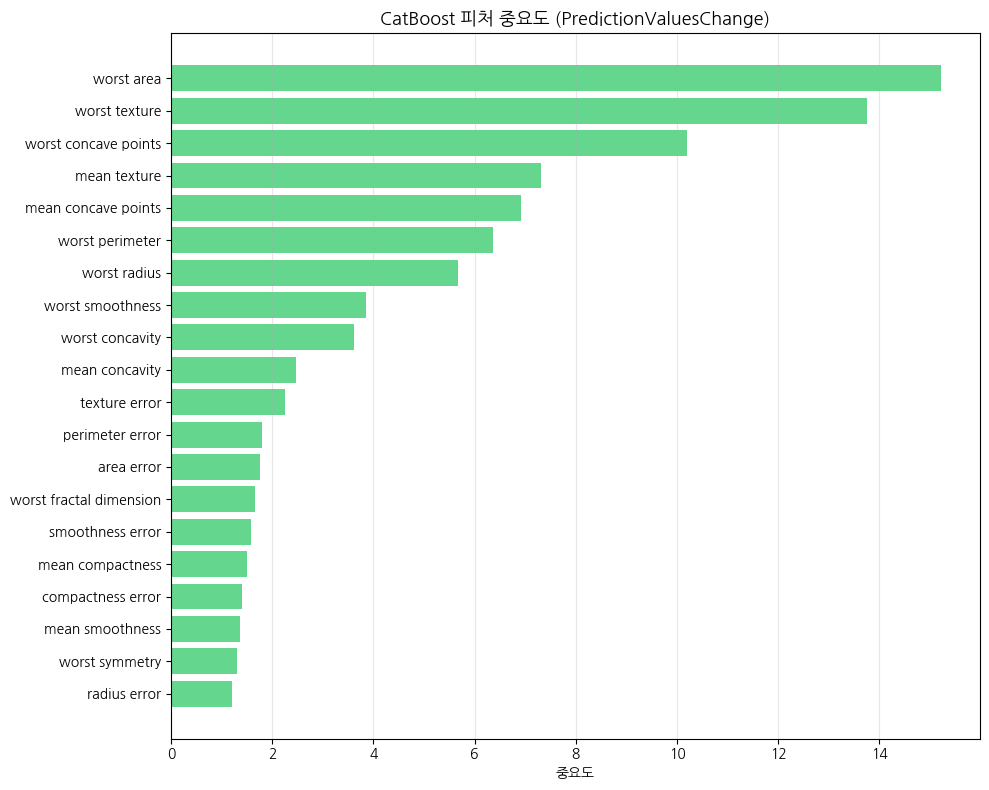

In [ ]:
# 피처 중요도 시각화
feature_importance = cat_clf.get_feature_importance(
    data = test_pool,
    type = 'PredictionValuesChange' # 피처 제거 시 예측값 변화량
)
feature_names = X_train.columns.tolist()
sorted_idx = np.argsort(feature_importance)
top_n = 20

fig, ax = plt.subplots(figsize=(10,8))
ax.barh(
    [feature_names[i] for i in sorted_idx[-top_n:]],
    feature_importance[sorted_idx[-top_n:]],
    color='#22c55e', alpha=0.7 # alpha 값 추가
)
ax.set_title('CatBoost 피처 중요도 (PredictionValuesChange)', fontsize=13)
ax.set_xlabel('중요도')
ax.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.show()

### XGBoost vs LightGBM vs CatBoost 최종 비교

In [ ]:
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping as XGBEarlyStopping

from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping as LGBEarlyStopping

from catboost import CatBoostClassifier, Pool

import time

In [32]:
results = {}

# XGBoost
t0 = time.time()
xgb_cmp = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    eval_metric = 'logloss',
    random_state = 42,
    callbacks = [XGBEarlyStopping(rounds=50, save_best=True, maximize=False)]
)
xgb_cmp.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    verbose = False
)
t_xgb = time.time() - t0
p_xgb = xgb_cmp.predict(X_test)
pp_xgb = xgb_cmp.predict_proba(X_test)[:, 1]
results['XGBoost'] = {
    '정확도': accuracy_score(y_test, p_xgb),
    'AUC': roc_auc_score(y_test, pp_xgb),
    '학습시간': t_xgb,
    '최적라운드': xgb_cmp.best_iteration
}

# LightGBM
t0 = time.time()
lgbm_cmp = LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    num_leaves = 31,
    random_state = 42,
    verbose = -1
)
lgbm_cmp.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    eval_metric = 'logloss',
    callbacks = [LGBEarlyStopping(stopping_rounds=50, verbose=False)]
)
t_lgbm = time.time() - t0
p_lgbm = lgbm_cmp.predict(X_test)
pp_lgbm = lgbm_cmp.predict_proba(X_test)[:, 1]
results['LightGBM'] = {
    '정확도': accuracy_score(y_test, p_lgbm),
    'AUC': roc_auc_score(y_test, pp_lgbm),
    '학습시간': t_lgbm,
    '최적라운드': lgbm_cmp.best_iteration_
}

# CatBoost
cat_cols = [] # 범주형 컬럼명 리스트 ['컬럼명', '컬럼명']
cal_features_idx = [X_train.columns.tolist().index(c) for c in cat_cols]

train_pool = Pool(X_tr, y_tr, cat_features=cal_features_idx)
val_pool = Pool(X_val, y_val, cat_features=cal_features_idx)
test_pool = Pool(X_test, y_test, cat_features=cal_features_idx)

t0 = time.time()
cat_cmp = CatBoostClassifier(
    iterations = 500,
    learning_rate = 0.05,
    depth = 6,
    loss_function = 'Logloss',
    random_seed = 42,
    verbose = False
)
cat_cmp.fit(
    train_pool,
    eval_set = val_pool,
    early_stopping_rounds = 50,
)
t_cat = time.time() - t0
p_cat = cat_cmp.predict(test_pool)
pp_cat = cat_cmp.predict_proba(test_pool)[:, 1]
results['CatBoost'] = {
    '정확도': accuracy_score(y_test, p_cat),
    'AUC': roc_auc_score(y_test, pp_cat),
    '학습시간': t_cat,
    '최적라운드': cat_cmp.best_iteration_
}

In [33]:
cmp_df = pd.DataFrame(results).T
cmp_df['정확도']         = cmp_df['정확도'].round(4)
cmp_df['AUC']          = cmp_df['AUC'].round(4)
cmp_df['학습시간'] = cmp_df['학습시간'].apply(lambda x: f'{x:.2f}초')
cmp_df['최적라운드'] = cmp_df['최적라운드'].astype(int)
print('===3종 GBM 비교 (위스콘신 유방암) ===')
display(cmp_df)

===3종 GBM 비교 (위스콘신 유방암) ===


,정확도,AUC,학습시간,최적라운드
XGBoost,0.9737,0.9947,0.65초,104
LightGBM,0.9561,0.9877,0.15초,61
CatBoost,0.9298,0.9933,2.23초,108


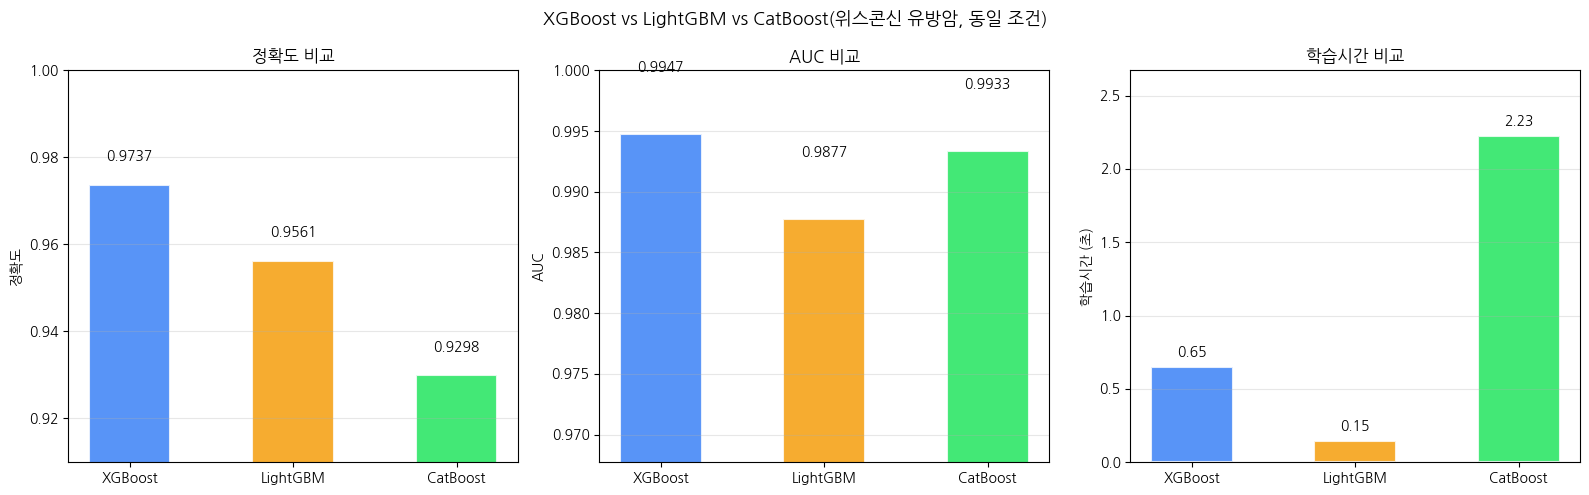

In [36]:
# 시각화: 4개 지표 동시 비교
models = list(results.keys())
colors = ['#3b82f6', '#f59e0b','#22e55e']

acc = [results[m]['정확도'] for m in models]
auc = [results[m]['AUC'] for m in models]
time_taken = [results[m]['학습시간'] for m in models]
rounds = [results[m]['최적라운드'] for m in models]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 정확도 비교
bars0 = axes[0].bar(models, acc, color=colors, alpha=0.85,
                    width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(min(acc)-0.02, 1.0)
axes[0].set_ylabel('정확도')
axes[0].set_title('정확도 비교')
axes[0].grid(axis='y', alpha=0.3)
for bar in bars0:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

# AUC 비교
bars1 = axes[1].bar(models, auc, color=colors, alpha=0.85,
                    width=0.5, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(min(auc)-0.02, 1.0)
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC 비교')
axes[1].grid(axis='y', alpha=0.3)
for bar in bars1:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

# 학습시간 비교
bars2 = axes[2].bar(models, time_taken, color=colors, alpha=0.85,
                    width=0.5, edgecolor='white', linewidth=1.5)
axes[2].set_ylim(0, max(time_taken) * 1.2)
axes[2].set_ylabel('학습시간 (초)')
axes[2].set_title('학습시간 비교')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars2:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.suptitle('XGBoost vs LightGBM vs CatBoost(위스콘신 유방암, 동일 조건)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()